# Confronto tra allineamento fullsize e con griglia

Questo notebook ha l'obiettivo di visualizzare se ci sono differenze tra allineare prima l'immagine intera e poi suddividerla, o prima suddividerla e poi allineare le sottoimmagini. Se ci sono differenze vogliamo trovare il metodo migliore.

# Definizioni iniziali

#### Pacchetti

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Confronto

#### Apertura delle immagini intere

In [20]:
label_free = cv2.imread("../../Materiale/Locale/fullsize_label_free.tif")
mask_lf = cv2.imread("../../Materiale/Immagini/mask_label_free.tif", cv2.IMREAD_GRAYSCALE)
stained = cv2.imread("../../Materiale/Locale/fullsize_stained.tif")
mask_st = cv2.imread("../../Materiale/Immagini/mask_stained.tif", cv2.IMREAD_GRAYSCALE)
aligned_stained = cv2.imread("../../Materiale/Locale/aligned_stained.tif")
aligned_mask_st = cv2.imread("../../Materiale/Immagini/aligned_mask_stained.tif", cv2.IMREAD_GRAYSCALE)

#### Estrazione delle porzioni

In [21]:
portion = (10000, 10000, 14000, 14000) # x1, y1, x2, y2
margin = 200
portion_label_free = label_free[portion[1]-margin:portion[3]+margin, portion[0]-margin:portion[2]+margin]
portion_mask_lf = mask_lf[portion[1]-margin:portion[3]+margin, portion[0]-margin:portion[2]+margin]
portion_stained = stained[portion[1]-margin:portion[3]+margin, portion[0]-margin:portion[2]+margin]
portion_mask_st = mask_st[portion[1]-margin:portion[3]+margin, portion[0]-margin:portion[2]+margin]
portion_aligned_stained = aligned_stained[portion[1]:portion[3], portion[0]:portion[2]]
portion_aligned_mask_st = aligned_mask_st[portion[1]:portion[3], portion[0]:portion[2]]

#### Allineamento delle porzioni

In [22]:
# Applicazione CLAHE
clahe = cv2.createCLAHE(clipLimit=18.0, tileGridSize=(8, 8))
label_free_clahe = clahe.apply(cv2.cvtColor(portion_label_free, cv2.COLOR_BGR2GRAY))
stained_clahe = clahe.apply(cv2.cvtColor(portion_stained, cv2.COLOR_BGR2GRAY))

# Calcolo delle features con SIFT
sift = cv2.SIFT_create(nfeatures=10000)
keypoints_1, descriptors_1 = sift.detectAndCompute(label_free_clahe, mask=portion_mask_lf)
keypoints_2, descriptors_2 = sift.detectAndCompute(stained_clahe, mask=portion_mask_st)

# Matching delle features
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors_1, descriptors_2)

# Filtraggio dei match con distanza euclidea
filtered_matches = []
for match in matches:
    distance = np.linalg.norm(np.array(keypoints_1[match.queryIdx].pt) - np.array(keypoints_2[match.trainIdx].pt))
    if distance <= 200:
        filtered_matches.append(match)

# Estrazione dei punti
points_1 = np.float32([keypoints_1[match.queryIdx].pt for match in filtered_matches]).reshape(-1, 1, 2)
points_2 = np.float32([keypoints_2[match.trainIdx].pt for match in filtered_matches]).reshape(-1, 1, 2)

# Calcolo della matrice di trasformazione
warp_matrix, mask = cv2.estimateAffinePartial2D(points_2, points_1)
print("Matrice di trasformazione:\n", warp_matrix)

# Allineamento dell'immagine e della maschera
new_aligned_portion = cv2.warpAffine(portion_stained, warp_matrix, (portion_label_free.shape[1], portion_label_free.shape[0]))
new_aligned_mask_portion = cv2.warpAffine(portion_mask_st, warp_matrix, (portion_label_free.shape[1], portion_label_free.shape[0]))

# Rimozione del margine
new_aligned_portion = new_aligned_portion[margin:-margin, margin:-margin]
new_aligned_mask_portion = new_aligned_mask_portion[margin:-margin, margin:-margin]

Matrice di trasformazione:
 [[ 1.00023450e+00  2.61744041e-03  1.56512869e+01]
 [-2.61744041e-03  1.00023450e+00 -1.05033335e+02]]


#### Confronto

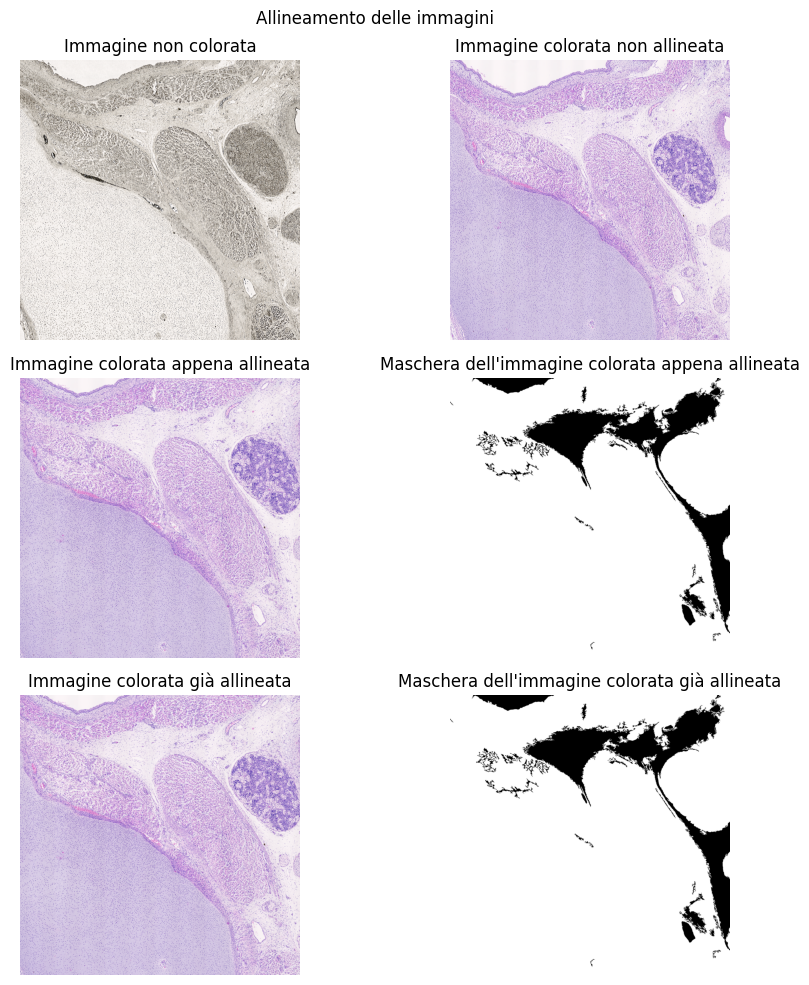

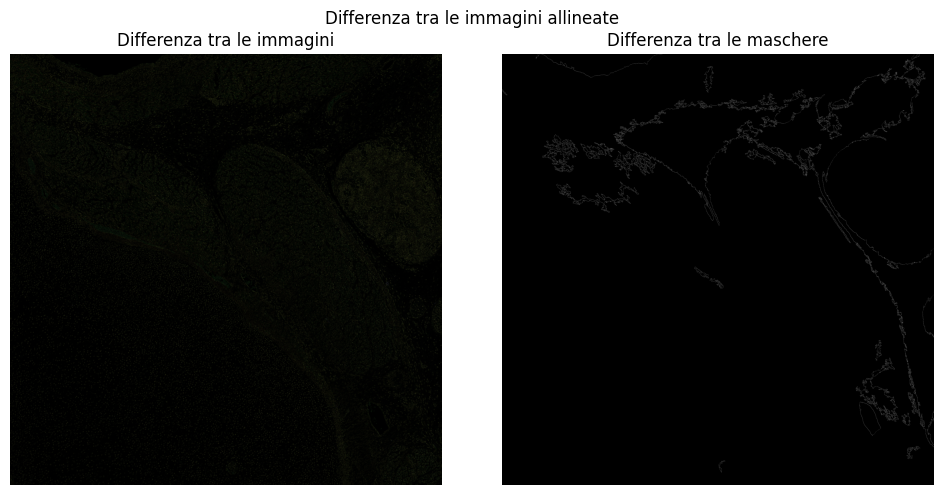

Mean Squared Error (MSE): 24.833615083333335


In [25]:
figure, subplots = plt.subplots(3, 2, figsize=(10, 10))
figure.suptitle("Allineamento delle immagini")
subplots[0, 0].imshow(cv2.cvtColor(portion_label_free, cv2.COLOR_BGR2RGB))
subplots[0, 0].set_title("Immagine non colorata")
subplots[0, 0].axis("off")
subplots[0, 1].imshow(cv2.cvtColor(portion_stained, cv2.COLOR_BGR2RGB))
subplots[0, 1].set_title("Immagine colorata non allineata")
subplots[0, 1].axis("off")
subplots[1, 0].imshow(cv2.cvtColor(new_aligned_portion, cv2.COLOR_BGR2RGB))
subplots[1, 0].set_title("Immagine colorata appena allineata")
subplots[1, 0].axis("off")
subplots[1, 1].imshow(cv2.cvtColor(new_aligned_mask_portion, cv2.COLOR_BGR2RGB))
subplots[1, 1].set_title("Maschera dell'immagine colorata appena allineata")
subplots[1, 1].axis("off")
subplots[2, 0].imshow(cv2.cvtColor(portion_aligned_stained, cv2.COLOR_BGR2RGB))
subplots[2, 0].set_title("Immagine colorata già allineata")
subplots[2, 0].axis("off")
subplots[2, 1].imshow(cv2.cvtColor(portion_aligned_mask_st, cv2.COLOR_BGR2RGB))
subplots[2, 1].set_title("Maschera dell'immagine colorata già allineata")
subplots[2, 1].axis("off")
plt.tight_layout()
plt.show()

difference = cv2.absdiff(new_aligned_portion, portion_aligned_stained)
difference_mask = cv2.absdiff(new_aligned_mask_portion, portion_aligned_mask_st)
figure, subplots = plt.subplots(1, 2, figsize=(10, 5))
figure.suptitle("Differenza tra le immagini allineate")
subplots[0].imshow(cv2.cvtColor(difference, cv2.COLOR_BGR2RGB))
subplots[0].set_title("Differenza tra le immagini")
subplots[0].axis("off")
subplots[1].imshow(difference_mask, cmap="gray")
subplots[1].set_title("Differenza tra le maschere")
subplots[1].axis("off")
plt.tight_layout()
plt.show()

mse = np.mean((new_aligned_portion - portion_aligned_stained) ** 2)
print("Mean Squared Error (MSE):", mse)

# Risultati

Possiamo vedere che la differenza tra i due metodi è infinitesima, allo stesso livello dell'errore introdotto dalla rotazione di una immagine. Pertanto entrambi i metodi sono validi: utilizzare l'immagine intera già allineata permette di evitare di dover effettuare l'allineamento ogni volta, mentre allineare la sottogriglia permette di non dover caricare e ritagliare l'immagine intera, se non è necessaria tutta.